In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV
import pickle

df = pd.read_csv('../data/ACME-HappinessSurvey2020.csv')
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [2]:
def load_data():
    df = pd.read_csv("data/raw/customers.csv")
    return df

# EDA analysis

Checking data types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


Missing Values

In [4]:
df.isna().sum()/len(df)

Y     0.0
X1    0.0
X2    0.0
X3    0.0
X4    0.0
X5    0.0
X6    0.0
dtype: float64

In [5]:
def missing_data():
   missing = df.isna().sum()/len(df)
   return missing

Correlation matrix analysis

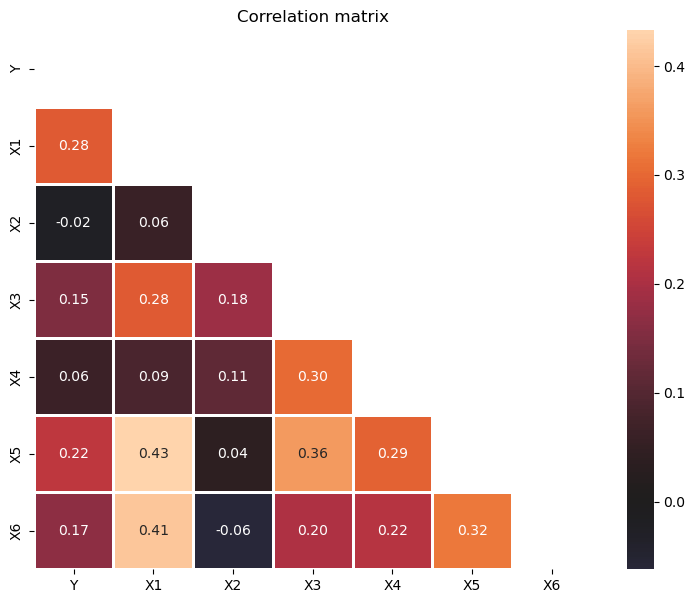

In [6]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr))
correlation_matrix = sns.heatmap(corr, center=0,
            mask=mask,
              linewidths=1,
              annot=True,
                fmt=".2f"
)
plt.savefig("../reports/figures/correlation_matrix.png")
plt.title("Correlation matrix")
plt.show()

In [7]:
def correlation_matrix():
    corr = df.select_dtypes(include='number').corr()
    plt.figure(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr))
    correlation_matrix = sns.heatmap(corr, center=0,
            mask=mask,
              linewidths=1,
              annot=True,
                fmt=".2f"
)
    plt.savefig("../reports/figures/correlation_matrix.png")
    plt.title("Correlation matrix")
    plt.show()
    return 

Outliers Analysis quantile method

In [8]:
def outlier_analysis(df, column):
    q1_q = df[column].quantile(0.25)
    q3_q = df[column].quantile(0.75)
    # Find the IQR
    IQR = q3_q - q1_q
    factor = 2.5 # 2.5 × IQR means you only mark really extreme points as outliers
    lower_limit_q = q1_q - IQR*factor
    upper_limit_q = q3_q + IQR*factor

    is_lower_q = df[column] < lower_limit_q

    is_higher_q = df[column] > upper_limit_q
    # Combine the masks to filter for outliers
    outliers = df[column][is_lower_q | is_higher_q] 
    # Count and print the number of outliers
    print(len(outliers))

In [9]:
outlier_analysis(df,"X1")

1


In [10]:
outlier_analysis(df,"X2")

0


In [11]:
outlier_analysis(df,"X3")

0


In [12]:
outlier_analysis(df,"X4")

0


In [13]:
outlier_analysis(df,"X5")

0


In [14]:
outlier_analysis(df,"X6")

1


Feature engineering is not part of this project as there are only 6 variables and I can not derive anything

# Building the models with functions

In [15]:
def split_data():
    y = df['Y']
    X = df.drop('Y',axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X, y,
        test_size=0.2, random_state=42, stratify= y )
    return X_train, X_test, y_train, y_test

In [16]:
X_train, X_test, y_train, y_test = split_data()

In [17]:
def train_model(model, X_train, y_train):
    model.fit(X_train, y_train)
    return model

In [18]:
def make_predictions(model, X_test):
    predictions = model.predict(X_test)
    return predictions

In [19]:
def classification_bymodel(predictions):
    labels = ["Not Happy", "Happy"]
    
    classification_report_model = classification_report(
    y_test,
    predictions,
    target_names=labels)
    
    return classification_report_model

KNN modeling

In [ ]:
knn = KNeighborsClassifier(n_neighbors=20,random_state =42)

trained_knn = train_model(knn, X_train, y_train)

In [90]:
with open("../models/knn.pkl", "wb") as file:
    pickle.dump(trained_knn, file)

In [27]:
knn_predictions = make_predictions(trained_knn, X_test)

In [29]:
knn_report = classification_bymodel(knn_predictions)

In [31]:
print(knn_report)

              precision    recall  f1-score   support

   Not Happy       0.71      0.42      0.53        12
       Happy       0.63      0.86      0.73        14

    accuracy                           0.65        26
   macro avg       0.67      0.64      0.63        26
weighted avg       0.67      0.65      0.63        26



Logistic Regression modeling

In [ ]:
logreg = LogisticRegression(random_state =42)

trained_logreg = train_model(logreg, X_train, y_train)

In [91]:
with open("../models/lr.pkl","wb") as file:
    pickle.dump(trained_logreg, file)

In [34]:
logreg_predictions = make_predictions(trained_logreg, X_test)

In [35]:
logreg_report = classification_bymodel(logreg_predictions)

In [36]:
print(logreg_report)

              precision    recall  f1-score   support

   Not Happy       0.67      0.33      0.44        12
       Happy       0.60      0.86      0.71        14

    accuracy                           0.62        26
   macro avg       0.63      0.60      0.58        26
weighted avg       0.63      0.62      0.59        26



SVM modeling

In [ ]:
svm = SVC(random_state =42)

trained_svm = train_model(svm, X_train, y_train)

In [92]:
with open("../models/svm.pkl", "wb") as file:
    pickle.dump(trained_svm,file)

In [44]:
svm_predictions = make_predictions(trained_svm, X_test)

In [45]:
svm_report = classification_bymodel(svm_predictions)

In [46]:
print(svm_report)

              precision    recall  f1-score   support

   Not Happy       0.67      0.33      0.44        12
       Happy       0.60      0.86      0.71        14

    accuracy                           0.62        26
   macro avg       0.63      0.60      0.58        26
weighted avg       0.63      0.62      0.59        26



Decision tree modeling

In [51]:
normal_tree = DecisionTreeClassifier(random_state=42,
                                     class_weight='balanced')

In [54]:
trained_normal_tree = train_model(normal_tree, X_train, y_train)

In [93]:
with open("../models/normal_tree.pkl", "wb") as file:
    pickle.dump(trained_normal_tree,file)

In [56]:
tree_predictions = make_predictions(trained_normal_tree,X_test)

In [57]:
tree_report = classification_bymodel(tree_predictions)

In [58]:
print(tree_report)

              precision    recall  f1-score   support

   Not Happy       0.53      0.75      0.62        12
       Happy       0.67      0.43      0.52        14

    accuracy                           0.58        26
   macro avg       0.60      0.59      0.57        26
weighted avg       0.60      0.58      0.57        26



Xgboost modeling 

In [59]:
xgboost = XGBClassifier(random_state =42)

trained_xgboost = train_model(xgboost,X_train,y_train)

In [94]:
with open("../models/xgboost.pkl", "wb") as file:
    pickle.dump(trained_xgboost,file)

In [61]:
xgboost_predications = make_predictions(trained_xgboost,X_test)

In [62]:
xgboost_report = classification_bymodel(xgboost_predications)

In [63]:
print(xgboost_report)

              precision    recall  f1-score   support

   Not Happy       0.42      0.42      0.42        12
       Happy       0.50      0.50      0.50        14

    accuracy                           0.46        26
   macro avg       0.46      0.46      0.46        26
weighted avg       0.46      0.46      0.46        26



Random Forest modeling 

In [66]:
rf = RandomForestClassifier(random_state=42,  
                            class_weight='balanced')
trained_rf = train_model(rf,X_train,y_train)

In [95]:
with open("../models/rf.pkl", "wb") as file:
    pickle.dump(trained_rf,file)

In [69]:
rf_predictions = make_predictions(trained_rf, X_test)

In [70]:
rf_report = classification_bymodel(rf_predictions)

In [71]:
print(rf_report)

              precision    recall  f1-score   support

   Not Happy       0.60      0.75      0.67        12
       Happy       0.73      0.57      0.64        14

    accuracy                           0.65        26
   macro avg       0.66      0.66      0.65        26
weighted avg       0.67      0.65      0.65        26



# Random Search 

In [ ]:

max_depth_list = list(range(2,40))
min_samples_split_list = list(range(2,20))
n_estimators_list = list(range(200,1000))
min_samples_leaf_list = list(range(2,10))

parameter_grid = {
'max_depth': max_depth_list,
'min_samples_split': min_samples_split_list,
'n_estimators' : n_estimators_list,
'min_samples_leaf' : min_samples_leaf_list
}

number_models = 10

random_RF_class = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=parameter_grid,
    n_iter=number_models,
    scoring='accuracy',
    n_jobs=-1,
    cv=5,
)
random_RF_class.fit(X_train, y_train)


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9,
                                                      10, 11, 12, 13, 14, 15,
                                                      16, 17, 18, 19, 20, 21,
                                                      22, 23, 24, 25, 26, 27,
                                                      28, 29, 30, 31, ...],
                                        'min_samples_leaf': [2, 3, 4, 5, 6, 7,
                                                             8, 9],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              8, 9, 10, 11, 12,
                                                              13, 14, 15, 16,
                                                              17, 18, 19],
                                        'n_estimators': [200, 201, 202, 203,
                                                         204, 205, 206, 207,
                                                         208, 209, 210, 211,
                                                         212, 213, 214, 215,
                                                         216, 217, 218, 219,
                                                         220, 221, 222, 223,
                                                         224, 225, 226, 227,
                                                         228, 229, ...]},
                   scoring='accuracy')

In [ ]:
rand_x = random_RF_class.cv_results_['param_max_depth']
rand_y = random_RF_class.cv_results_['param_min_samples_leaf']
rand_z = random_RF_class.cv_results_['param_n_estimators']
rand_w = random_RF_class.cv_results_['param_min_samples_split']

In [ ]:
print("max_depth:", rand_x)
print("min_samples_leaf:", rand_y)
print("n_estimators:", rand_z)
print("min_samples_split:", rand_w)

max_depth: [25 35 21 33 23 5 29 3 7 30]
min_samples_leaf: [7 9 5 9 3 6 4 8 9 6]
n_estimators: [577 840 629 236 616 321 577 759 489 285]
min_samples_split: [8 12 16 12 6 10 19 6 5 17]


In [ ]:
random_RF_class.best_params_

{'n_estimators': 629,
 'min_samples_split': 16,
 'min_samples_leaf': 5,
 'max_depth': 21}

# Optimized model

In [79]:
tuned_rf = RandomForestClassifier(random_state=42,  
                            class_weight='balanced',
                            max_depth = 17,
                            min_samples_leaf = 5,
                            min_samples_split = 6,
                            n_estimators = 675
                           )
trained_tuned_rf = train_model(rf_tuned, X_train, y_train)

In [96]:
with open("../models/rf_tuned.pkl","wb") as file:
    pickle.dump(trained_tuned_rf,file)

In [81]:
tuned_rf_predictions = make_predictions(trained_tuned_rf, X_test)

In [82]:
tuned_rf_report = classification_bymodel(tuned_rf_predictions)

In [83]:
print(tuned_rf_report)

              precision    recall  f1-score   support

   Not Happy       0.75      0.75      0.75        12
       Happy       0.79      0.79      0.79        14

    accuracy                           0.77        26
   macro avg       0.77      0.77      0.77        26
weighted avg       0.77      0.77      0.77        26



# Feature importance for feature selection

Feature importance helps identify which features the model relied on most heavily when making predictions. In this section, I progressed from a simple representation of feature importance to more advanced and informative visualization methods.

<BarContainer object of 6 artists>

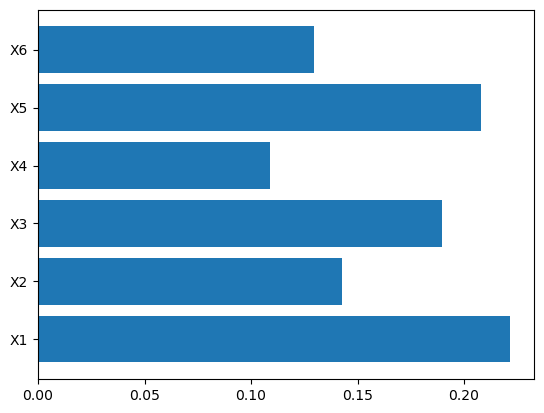

In [ ]:
plt.barh(X_train.columns,
         rf_tuned.feature_importances_)

In [88]:
def feature_importance(model, X_train):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    # A series is a better representation than using a dictionary 
    # index is needed for the labels
    top_features = importances.sort_values(ascending=False)
    # sort first for the importance, then sort again for the visual order of the values
    top_features.sort_values().plot(kind='barh', figsize=(12,6))
    # A horizontal bar chart is much better than a vertical bar chart to represent importance
    plt.title("Top 6 Feature Importances")
    plt.savefig("../reports/figures/feature_importance.png")
    plt.show()

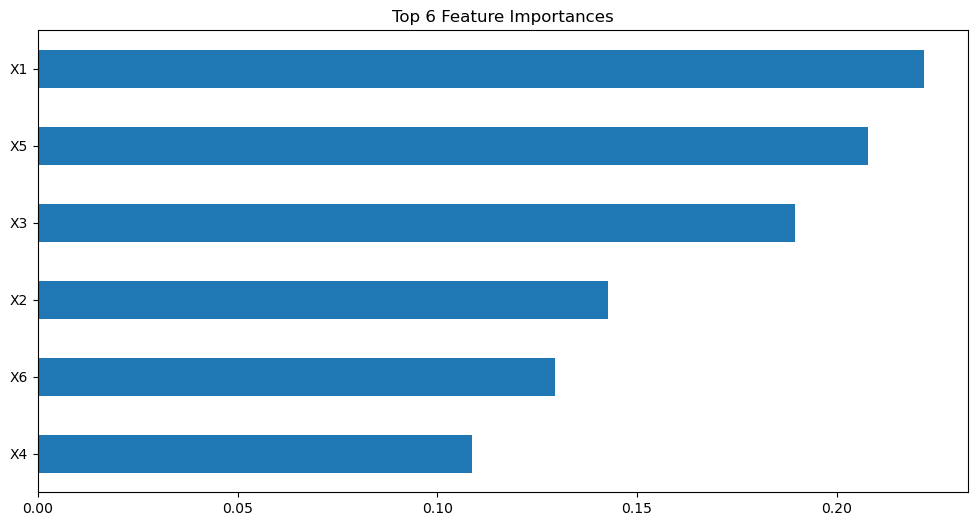

In [ ]:
feature_importance(trained_tuned_rf, X_train)

Findings: X1 is the most important feature for predicting customer happiness. X3 represents the statement, 'My order was delivered on time.' On the other hand, X4 is the least important feature, representing 'I paid a good price for my order.'

Number 1 is X1 = my order was delivered on time
Number 2 is X5 = I am satisfied with my courier
Number 3 is X3 = I ordered everything I wanted to order


# Permutation Feature Importance 

The idea is that if the signal of the features is shuffled and destroyed, how much effect will it have on the model on seen data.

In [ ]:
importance = pd.Series(permutation_importance(trained_tuned_rf, X_train, y_train, n_repeats=50).importances_mean, index=X_train.columns)
# shuffling each feature 50 times to provide a better result of stability 
print(importance.sort_values(ascending=False))

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

Conclusion: Interestingly, shuffling X1 results in an 11% drop in model performance, indicating that X1 represents a strong predictive signal for the model. Based on the feature importance results, retaining X1, X5, and X3 appears well justified. X6 and X2 could also be considered, while X4 could be considered for removal, as it provides the weakest predictive signal among the features.